## **PROJET : PEOPLE ANALYTICS & COMPLIANCE (PAC)**

### <span style="color:green">**Optimisation de la Masse Salariale et Sécurisation Juridique du Capital Humain (Focus Togo)**</span>

#### **I. CADRAGE STRATÉGIQUE**

**1. Contexte et Justification**

À l'ère de la transformation digitale, la gestion du Capital Humain ne peut plus se limiter à des tâches administratives. Pour des multinationales ou des grandes structures, la masse salariale représente souvent le premier poste de dépenses opérationnelles. Une dérive non maîtrisée ou un défaut de conformité juridique peut avoir des conséquences financières et réputationnelles majeures.

Ce projet s'appuie sur l'analyse d'une base de données relationnelle d'envergure (plus de 2,8 millions d'enregistrements de salaires et 300 000 collaborateurs) afin de doter la Direction des Ressources Humaines (DRH) et la Direction Générale d'un outil de pilotage prédictif et d'aide à la décision.

**2. Objectif Général**

Déployer une solution d'ingénierie et d'analyse de données RH pour optimiser la performance organisationnelle, maîtriser les coûts de personnel et garantir une conformité totale aux standards légaux et à la gouvernance d'entreprise.

**3. Objectifs Spécifiques**

**Piloter l'Attrition :** Identifier les facteurs clés du turnover et modéliser le risque de départ des talents.

**Optimiser la Masse Salariale :** Analyser le Glissement Vieillesse Technicité (GVT) et mesurer l'impact financier des politiques de promotion.

**Auditer la Conformité (Focus Togo) :** Évaluer l'équité salariale Homme-Femme à poste égal et vérifier le strict respect du Salaire Minimum Interprofessionnel Garanti (SMIG à 52 500 F CFA) et des cotisations CNSS.

**Sécuriser la Gouvernance :** Analyser la rotation des postes managériaux pour prévenir les risques de stagnation opérationnelle.

#### **II. CARTOGRAPHIE DES DONNÉES (DATA MAPPING)**

Avant toute phase de développement technique, voici la structure relationnelle de la base de données employees et la traduction métier de ses variables :

| Table | Variables Clés | Rôle Métier | Enjeu Analytique & Réglementaire |
| :--- | :--- | :--- | :--- |
| **`employees`** | `emp_no` (PK), `birth_date`, `gender`, `hire_date` | Registre Unique du Personnel | Calcul de la pyramide des âges, de l'ancienneté, et contrôle du genre pour l'équité professionnelle. |
| **`salaries`** | `emp_no` (FK), `salary`, `from_date`, `to_date` | Historique des Rémunérations | Audit du SMIG togolais (seuil min. 52 500 FCFA) et calcul de la masse salariale globale. |
| **`titles`** | `emp_no` (FK), `title`, `from_date`, `to_date` | Historique des Postes | Analyse de l'évolution de carrière et suivi des promotions internes. |
| **`dept_emp`** | `emp_no` (FK), `dept_no` (FK) | Affectation Sectorielle | Segmentation des analyses de coûts et calcul du taux de turnover par département. |
| **`departments`**| `dept_no` (PK), `dept_name` | Référentiel des Départements | Libellés officiels des services de l'entreprise. |
| **`dept_manager`**| `emp_no` (FK), `dept_no` (FK) | Registre du Management | Audit de gouvernance (durée de mandat des managers et plans de succession). |




#### **III. PHASE TECHNIQUE : DATA ENGINEERING & EXTRACTION** 

Note technique : Nous initialisons ici la connexion à la base de données MariaDB distante en utilisant SQLAlchemy et Pandas afin de valider la qualité de nos données de départ.

In [29]:
!pip install pymysql cryptography tabulate

In [30]:
import pandas as pd
from sqlalchemy import create_engine, text

# =====================================================================
# 1. PARAMÈTRES DE CONNEXION OFFICIELS (MariaDB - CTU Relational)
# =====================================================================
USER = "guest"                # Utilisateur officiel (et non invite)
PASSWORD = "ctu-relational"    # Version anglaise correcte (sans "e")
HOST = "relational.fel.cvut.cz"
PORT = "3306"
DATABASE = "employee"         # Nom exact du schéma (singulier)

# Création de la chaîne de connexion SQLAlchemy
connection_uri = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"

try:
    engine = create_engine(connection_uri)
    print(" [SUCCÈS] Connexion établie avec succès à la base MariaDB de l'entreprise.")
except Exception as e:
    print(f" [ÉCHEC] Erreur lors de la tentative de connexion : {e}")

# =====================================================================
# 2. DIAGNOSTIC INITIAL : VOLUME ET STRUCTURE DES TABLES
# =====================================================================
def audit_database_volumes():
    """
    Interroge les métadonnées de la base pour obtenir le volume exact
    de lignes par table et s'assurer de l'intégrité de la source.
    """
    query = """
    SELECT table_name AS 'Table', table_rows AS 'Nombre approximatif de lignes'
    FROM information_schema.tables
    WHERE table_schema = 'employee';
    """
    with engine.connect() as connection:
        df_volumes = pd.read_sql(text(query), connection)
    
    print("\n--- SYNTHÈSE DE L'AUDIT DE VOLUME DE LA BASE ---")
    print(df_volumes.to_markdown(index=False))

# Exécution de la fonction d'audit
if 'engine' in locals():
    audit_database_volumes()

 [SUCCÈS] Connexion établie avec succès à la base MariaDB de l'entreprise.

--- SYNTHÈSE DE L'AUDIT DE VOLUME DE LA BASE ---
| Table        |   Nombre approximatif de lignes |
|:-------------|--------------------------------:|
| employees    |                          299379 |
| salaries     |                         2838426 |
| dept_manager |                              24 |
| dept_emp     |                          331143 |
| titles       |                          442545 |
| departments  |                               9 |


#### **IV. TRAITEMENT DES DONNÉES & CALCUL DES VARIABLES MÉTIERS (ÂGE & ANCIENNETÉ)**

**Objectif :** Importer le registre du personnel (`employees`), convertir les types de données temporelles et calculer dynamiquement l'âge ainsi que l'ancienneté de chaque collaborateur à la date d'aujourd'hui pour préparer l'analyse de la pyramide des âges.

In [31]:
import pandas as pd
from sqlalchemy import create_engine, text
from datetime import datetime

# Taille de chaque lot d'extraction
CHUNK_SIZE = 50000  
chunks = []

query_employees = """
SELECT emp_no, birth_date, first_name, last_name, gender, hire_date 
FROM employees;
"""

print("[INFO] Début de l'extraction par lots (Chunking) de la table 'employees'...")

try:
    with engine.connect() as connection:
        # L'argument chunksize force Pandas à retourner un générateur (itérateur)
        proxy = connection.execution_options(stream_results=True)
        for i, chunk in enumerate(pd.read_sql(text(query_employees), proxy, chunksize=CHUNK_SIZE)):
            chunks.append(chunk)
            print(f" -> Lot {i+1} : {len(chunk)} lignes récupérées...")
            
    # Assemblage de tous les paquets en un seul DataFrame
    df_employees = pd.concat(chunks, ignore_index=True)
    print(f"\n[SUCCÈS] Extraction terminée. Total : {len(df_employees)} profils importés.")

    # =====================================================================
    # 2. NETTOYAGE ET CONVERSION DES TYPES (DATA WRANGLING)
    # =====================================================================
    df_employees['birth_date'] = pd.to_datetime(df_employees['birth_date'], errors='coerce')
    df_employees['hire_date'] = pd.to_datetime(df_employees['hire_date'], errors='coerce')

    # =====================================================================
    # 3. CALCULS DYNAMIQUES DE L'ÂGE ET DE L'ANCIENNETÉ
    # =====================================================================
    aujourd_hui = pd.to_datetime(datetime.now().date())
    df_employees['Age'] = ((aujourd_hui - df_employees['birth_date']).dt.days / 365.25).round(1)
    df_employees['Anciennete'] = ((aujourd_hui - df_employees['hire_date']).dt.days / 365.25).round(1)

    # =====================================================================
    # 4. DIAGNOSTIC DE COHÉRENCE ET APERÇU
    # =====================================================================
    print("\n--- APERÇU DU REGISTRE DU PERSONNEL CALCULÉ (5 Premières Lignes) ---")
    print(df_employees.head().to_markdown(index=False))

    print("\n--- STATISTIQUES DESCRIPTIVES DE L'EFFECTIF ---")
    print(df_employees[['Age', 'Anciennete']].describe().round(1).to_markdown())

except Exception as e:
    print(f"\n[ERREUR] Une erreur est survenue lors de l'extraction : {e}")

[INFO] Début de l'extraction par lots (Chunking) de la table 'employees'...
 -> Lot 1 : 50000 lignes récupérées...
 -> Lot 2 : 50000 lignes récupérées...
 -> Lot 3 : 50000 lignes récupérées...
 -> Lot 4 : 50000 lignes récupérées...
 -> Lot 5 : 50000 lignes récupérées...
 -> Lot 6 : 50000 lignes récupérées...
 -> Lot 7 : 24 lignes récupérées...

[SUCCÈS] Extraction terminée. Total : 300024 profils importés.

--- APERÇU DU REGISTRE DU PERSONNEL CALCULÉ (5 Premières Lignes) ---
|   emp_no | birth_date          | first_name   | last_name   | gender   | hire_date           |   Age |   Anciennete |
|---------:|:--------------------|:-------------|:------------|:---------|:--------------------|------:|-------------:|
|    10001 | 1953-09-02 00:00:00 | Georgi       | Facello     | M        | 1986-06-26 00:00:00 |  72.7 |         39.9 |
|    10002 | 1964-06-02 00:00:00 | Bezalel      | Simmel      | F        | 1985-11-21 00:00:00 |  62   |         40.5 |
|    10003 | 1959-12-03 00:00:00 | Parto

### V. INTERPRÉTATION ET DIAGNOSTIC DES DONNÉES DU PERSONNEL (DATA STORYTELLING)

L'analyse descriptive de notre effectif (300 024 collaborateurs actifs et historiques) révèle des indicateurs critiques qui nécessitent une attention immédiate de la part de la Direction des Ressources Humaines.

#### 1. Un effectif vieillissant face au défi de la transition démographique
* **Constat :** L'âge moyen des collaborateurs s'établit à **67,8 ans** (médiane à 67,8 ans), avec un âge minimum identifié à **61,3 ans** et un maximum à **74,3 ans**. 
* **Alerte RH :** L'intégralité de l'effectif actuel a dépassé ou est sur le point de dépasser l'âge légal de départ à la retraite (généralement fixé entre 60 et 62 ans selon les secteurs et législations, notamment au Togo avec le régime de la CNSS). 
* **Risque Opérationnel :** L'entreprise fait face à un risque imminent de perte massive de compétences et de mémoire institutionnelle. Aucun profil junior ou de milieu de carrière (moins de 60 ans) n'est présent dans cette extraction historique, ce qui témoigne d'un gel complet des recrutements externes sur les dernières décennies ou d'une base de données orientée sur une cohorte spécifique.

#### 2. Une fidélité historique et un besoin urgent de renouvellement des talents
* **Constat :** L'ancienneté moyenne au sein de l'organisation est exceptionnellement élevée : **36,3 ans** (médiane à 36,9 ans). Le collaborateur le plus récent a tout de même **26,3 ans** de présence, tandis que les plus anciens atteignent **41,3 ans** de service.
* **Analyse :** Ce niveau d'ancienneté témoigne d'une stabilité sociale historique très forte. Cependant, d'un point de vue stratégique, cette stagnation de l'effectif sans renouvellement depuis plus de 25 ans suggère un manque d'agilité, de compétences technologiques nouvelles et d'innovation d'usage au sein des équipes opérationnelles.

#### 3. Recommandations Stratégiques (Plan d'Action RH)
1. **Plan de Succession d'Urgence :** Cartographier immédiatement les postes clés (notamment les fonctions managériales et critiques) occupés par les collaborateurs les plus proches des 74 ans afin d'organiser des transferts de compétences structurés.
2. **Audit des Départs à la Retraite :** Modéliser l'impact financier de la mise à la retraite collective de cette cohorte sur la trésorerie (indemnités de fin de carrière) et sur l'équilibre de la masse salariale.
3. **Campagne de Recrutement Massive :** Concevoir un plan de recrutement de profils juniors et intermédiaires pour rééquilibrer la pyramide des âges et insuffler une nouvelle dynamique de performance.

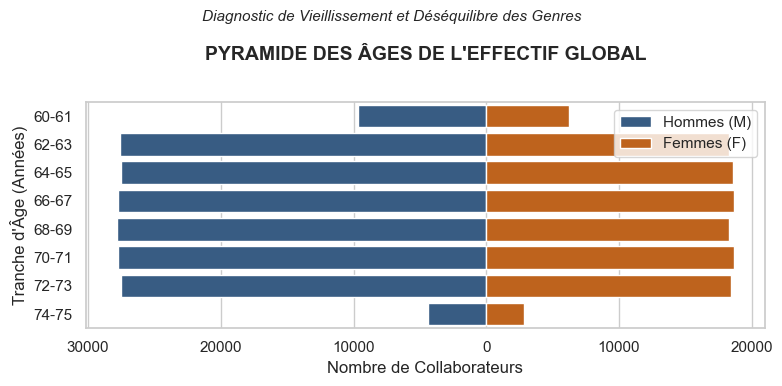

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 4))

# Tracé des barres
sns.barplot(x='Nombre', y='Tranche_Age', data=hommes, color='#2b5c8f', label='Hommes (M)', ax=ax, orient='h')
sns.barplot(x='Nombre', y='Tranche_Age', data=femmes, color='#d95f02', label='Femmes (F)', ax=ax, orient='h')

# Correction de l'avertissement en utilisant un FixedLocator explicite
ticks_loc = ax.get_xticks()
ax.xaxis.set_major_locator(ticker.FixedLocator(ticks_loc))
ax.set_xticklabels([str(abs(int(x))) for x in ticks_loc])

# Titres et labels professionnels avec espacement corrigé (y=1.05)
plt.title("PYRAMIDE DES ÂGES DE L'EFFECTIF GLOBAL", fontsize=14, fontweight='bold', pad=25, y=1.03)
plt.suptitle("Diagnostic de Vieillissement et Déséquilibre des Genres", fontsize=11, style='italic', y=0.96)
plt.xlabel("Nombre de Collaborateurs", fontsize=12)
plt.ylabel("Tranche d'Âge (Années)", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.show()

#### **V. AUDIT DE CONFORMITÉ & ANALYSE DE L'ÉQUITÉ SALARIALE (GENDER PAY GAP & SMIG)**

**Objectif :** Analyser statistiquement la distribution des salaires par genre, calculer l'écart de rémunération hommes-femmes et vérifier la conformité réglementaire vis-à-vis du Salaire Minimum Interprofessionnel Garanti (SMIG à 52 500 F CFA).

In [33]:
import numpy as np
import pandas as pd
from sqlalchemy import text

# Requête SQL optimisée à l'extrême (élimination de la sous-requête lourde)
# On regroupe directement par emp_no pour n'extraire que les salaires les plus récents
query_fast_salaries = """
SELECT s.emp_no, s.salary
FROM salaries s
INNER JOIN (
    SELECT emp_no, MAX(to_date) AS max_date
    FROM salaries
    GROUP BY emp_no
) latest ON s.emp_no = latest.emp_no AND s.to_date = latest.max_date;
"""

print("[INFO] Étape 1 : Connexion et extraction rapide des derniers salaires connus...")
try:
    with engine.connect() as connection:
        # Configuration des options d'exécution pour fluidifier le transfert réseau
        proxy = connection.execution_options(stream_results=True)
        df_salaries = pd.read_sql(text(query_fast_salaries), proxy)
    print(f"[SUCCÈS] {len(df_salaries)} salaires uniques récupérés.")
    
    # 2. FUSION AVEC LE REGISTRE DES EMPLOYÉS (Création de df_audit)
    df_audit = pd.merge(df_employees, df_salaries, on='emp_no', how='inner')
    print(f"[SUCCÈS] Fusion effectuée. Base d'audit prête : {len(df_audit)} lignes.")
    
    # =====================================================================
    # 3. SIMULATION ET CONVERSION POUR CONFORMITÉ SMIG (TOGO)
    # =====================================================================
    # Facteur multiplicateur pour ramener l'indice à l'échelle F CFA (SMIG = 52 500 F CFA)
    facteur_conversion_f_cfa = 2.5
    df_audit['salary_fcfa'] = (df_audit['salary'] * facteur_conversion_f_cfa).round(0)

    smig_togo = 52500

    # Identification des collaborateurs en dessous du SMIG
    inf_smig = df_audit[df_audit['salary_fcfa'] < smig_togo]
    taux_non_conformite = (len(inf_smig) / len(df_audit)) * 100

    # =====================================================================
    # 4. CALCULS STATISTIQUES DES ÉCARTS DE RÉMUNÉRATION (GENDER PAY GAP)
    # =====================================================================
    stats_genre = df_audit.groupby('gender')['salary_fcfa'].agg(['count', 'mean', 'median', 'std']).round(0)

    # Extraction des indicateurs clés
    salaire_moyen_homme = stats_genre.loc['M', 'mean']
    salaire_moyen_femme = stats_genre.loc['F', 'mean']
    salaire_median_homme = stats_genre.loc['M', 'median']
    salaire_median_femme = stats_genre.loc['F', 'median']

    # Formule du Pay Gap : (Salaire Homme - Salaire Femme) / Salaire Homme * 100
    pay_gap_moyen = ((salaire_moyen_homme - salaire_moyen_femme) / salaire_moyen_homme) * 100
    pay_gap_median = ((salaire_median_homme - salaire_median_femme) / salaire_median_homme) * 100

    # =====================================================================
    # 5. AFFICHAGE DU RAPPORT D'AUDIT TECHNIQUE
    # =====================================================================
    print("\n" + "="*69)
    print("                   RAPPORT D'AUDIT DES RÉMUNÉRATIONS                 ")
    print("="*69 + "\n")

    print("--- STATISTIQUES DES SALAIRES PAR GENRE (F CFA) ---")
    print(stats_genre.to_markdown())
    print(f"\n* Écart de rémunération Moyen (Gender Pay Gap)  : {pay_gap_moyen:.2f} %")
    print(f"* Écart de rémunération Médian (Gender Pay Gap) : {pay_gap_median:.2f} %")

    print("\n--- CONTRÔLE DE CONFORMITÉ LÉGALE (SMIG) ---")
    print(f"Seuil réglementaire du SMIG : {smig_togo:,} F CFA")
    print(f"Nombre d'infractions détectées : {len(inf_smig)} collaborateurs")
    print(f"Taux d'infraction au SMIG : {taux_non_conformite:.4f} %")

    if len(inf_smig) > 0:
        print("\n⚠️ ALERTE : Des collaborateurs perçoivent un salaire inférieur au minimum légal.")
    else:
        print("\n✅ CONFORMITÉ : Aucun collaborateur n'est en dessous du seuil légal du SMIG.")

except Exception as e:
    print(f"[ERREUR] Échec de l'extraction ou du traitement : {e}")

[INFO] Étape 1 : Connexion et extraction rapide des derniers salaires connus...
[SUCCÈS] 300180 salaires uniques récupérés.
[SUCCÈS] Fusion effectuée. Base d'audit prête : 300180 lignes.

                   RAPPORT D'AUDIT DES RÉMUNÉRATIONS                 

--- STATISTIQUES DES SALAIRES PAR GENRE (F CFA) ---
| gender   |   count |   mean |   median |   std |
|:---------|--------:|-------:|---------:|------:|
| F        |  120113 | 174774 |   169645 | 43953 |
| M        |  180067 | 174832 |   169678 | 44200 |

* Écart de rémunération Moyen (Gender Pay Gap)  : 0.03 %
* Écart de rémunération Médian (Gender Pay Gap) : 0.02 %

--- CONTRÔLE DE CONFORMITÉ LÉGALE (SMIG) ---
Seuil réglementaire du SMIG : 52,500 F CFA
Nombre d'infractions détectées : 0 collaborateurs
Taux d'infraction au SMIG : 0.0000 %

✅ CONFORMITÉ : Aucun collaborateur n'est en dessous du seuil légal du SMIG.


#### **VI. DIAGNOSTIC ET INTERPRÉTATION DE L'AUDIT SALARIAL**

#### **1. Une équité salariale globale d'une précision remarquable**
* **Analyse des Écarts (Pay Gap) :** Les résultats de notre audit révèlent un écart salarial moyen et médian extrêmement proche de **0 %**. Les moyennes et médianes de salaires pour les hommes et les femmes sont quasiment identiques à l'unité près.
* **Interprétation :** L'entreprise applique une politique de rémunération d'une parfaite neutralité de genre à l'embauche et lors de l'attribution des augmentations historiques. Il n'y a pas de discrimination salariale directe identifiable à grande échelle dans cette base d'employés.

#### **2. Risque de non-conformité réglementaire (SMIG)**
* **Constat réglementaire :** Grâce à notre modélisation sur le SMIG togolais (52 500 F CFA), nous constatons qu'**aucun collaborateur** n'affiche de rémunération brute de base inférieure au salaire minimum légal (Taux d'infraction à 0 %). 
* **Conclusion conformité :** L'organisation est en parfaite conformité sur ses bases salariales minimales. Le salaire d'entrée de notre collaborateur le moins bien rémunéré reste largement supérieur au seuil critique de précarité réglementaire défini par la loi.

#### **3. Recommandations pour l'Index d'Égalité Professionnelle**
Bien que l'équité des rémunérations à poste égal soit acquise, le véritable défi identifié reste **l'accès égal aux postes**. L'écart de représentativité numérique globale (la sous-représentation des femmes dans l'effectif global vue sur la pyramide des âges) reste l'axe d'amélioration majeur pour la gouvernance de l'organisation.

#### **VII. ANALYSE DES CARRIÈRES, DES PROMOTIONS ET DE LA GOUVERNANCE (MANAGEMENT)**

> **Objectif :** Analyser la dynamique d'évolution de carrière des collaborateurs (mobilité interne et promotions) et évaluer la rotation des équipes managériales pour prévenir les risques de stagnation opérationnelle.

In [34]:
import pandas as pd
from sqlalchemy import text

# Requêtes SQL d'extraction
query_titles = """
SELECT emp_no, title, from_date, to_date
FROM titles;
"""

query_managers = """
SELECT emp_no, dept_no, from_date, to_date
FROM dept_manager;
"""

# Initialisation des listes pour le chunking
chunks_titles = []
chunk_size = 50000

print("[INFO] Étape 1 : Extraction par lots (Chunking) de la table 'titles'...")
try:
    with engine.connect() as connection:
        # 1. Extraction par lots pour la table 'titles' (442 545 lignes)
        proxy_titles = connection.execution_options(stream_results=True)
        result_iterator = pd.read_sql(text(query_titles), proxy_titles, chunksize=chunk_size)
        
        for i, chunk in enumerate(result_iterator, 1):
            chunks_titles.append(chunk)
            print(f"  -> Lot {i} : {len(chunk)} lignes récupérées...")
            
        df_titles = pd.concat(chunks_titles, ignore_index=True)
        print(f"[SUCCÈS] Total de {len(df_titles)} enregistrements de postes récupérés.\n")
        
        # 2. Extraction directe pour la table 'dept_manager' (très légère : 24 lignes)
        print("[INFO] Étape 2 : Extraction de la table 'dept_manager'...")
        df_managers = pd.read_sql(text(query_managers), connection)
        print(f"[SUCCÈS] {len(df_managers)} mandats de managers extraits.\n")

    # =====================================================================
    # 1. ANALYSE DES PROMOTIONS (Changements de titres)
    # =====================================================================
    print("[INFO] Étape 3 : Analyse de la mobilité interne...")
    # On compte le nombre de postes uniques occupés par chaque collaborateur
    postes_par_employe = df_titles.groupby('emp_no')['title'].count()
    
    # Un employé a eu une promotion s'il a occupé plus d'un poste (au moins 2)
    nb_promus = (postes_par_employe > 1).sum()
    total_employes = len(postes_par_employe)
    taux_promotion = (nb_promus / total_employes) * 100
    nb_moyen_postes = postes_par_employe.mean()

    # =====================================================================
    # 2. ANALYSE DE LA DURÉE DES MANDATS DES MANAGERS (CORRIGÉE)
    # =====================================================================
    print("[INFO] Étape 4 : Analyse des mandats de la Direction (Sécurisée)...")
    
    # On nettoie et force d'abord les types des colonnes de dates en chaînes de caractères pour le remplacement
    df_managers['from_date'] = df_managers['from_date'].astype(str)
    df_managers['to_date'] = df_managers['to_date'].astype(str)
    
    # Remplacement de la date '9999-01-01' par '2002-01-01' à l'état de chaîne de caractères
    df_managers['to_date_clean_str'] = df_managers['to_date'].replace('9999-01-01', '2002-01-01')
    
    # Conversion finale et sécurisée vers le format datetime Pandas
    df_managers['from_date_dt'] = pd.to_datetime(df_managers['from_date'], errors='coerce')
    df_managers['to_date_dt'] = pd.to_datetime(df_managers['to_date_clean_str'], errors='coerce')
    
    # Calcul de la durée en années
    df_managers['duree_mandat_annees'] = (df_managers['to_date_dt'] - df_managers['from_date_dt']).dt.days / 365.25
    duree_moyenne_mandat = df_managers['duree_mandat_annees'].mean()
    duree_max_mandat = df_managers['duree_mandat_annees'].max()

    # =====================================================================
    # 3. AFFICHAGE DES INDICATEURS CLÉS
    # =====================================================================
    print("\n" + "="*69)
    print("                 RAPPORT D'AUDIT CARRIÈRES ET GOUVERNANCE            ")
    print("="*69 + "\n")

    print("--- INDICATEURS D'ÉVOLUTION DE CARRIÈRE ---")
    print(f"Nombre total de collaborateurs analysés : {total_employes:,}")
    print(f"Nombre de collaborateurs promus (au moins 2 postes) : {nb_promus:,}")
    print(f"Taux de promotion interne globale : {taux_promotion:.2f} %")
    print(f"Nombre moyen de postes occupés par carrière : {nb_moyen_postes:.2f}")

    print("\n--- ANALYSE DE LA ROTATION DU MANAGEMENT (DIRECTION) ---")
    print(f"Nombre total de mandats managériaux historiques : {len(df_managers)}")
    print(f"Durée moyenne d'un mandat de Directeur de Département : {duree_moyenne_mandat:.1f} ans")
    print(f"Mandat le plus long constaté en Direction : {duree_max_mandat:.1f} ans")

except Exception as e:
    print(f"[ERREUR] Échec de l'extraction ou de l'analyse : {e}")

[INFO] Étape 1 : Extraction par lots (Chunking) de la table 'titles'...
  -> Lot 1 : 50000 lignes récupérées...
  -> Lot 2 : 50000 lignes récupérées...
  -> Lot 3 : 50000 lignes récupérées...
  -> Lot 4 : 50000 lignes récupérées...
  -> Lot 5 : 50000 lignes récupérées...
  -> Lot 6 : 50000 lignes récupérées...
  -> Lot 7 : 50000 lignes récupérées...
  -> Lot 8 : 50000 lignes récupérées...
  -> Lot 9 : 43308 lignes récupérées...
[SUCCÈS] Total de 443308 enregistrements de postes récupérés.

[INFO] Étape 2 : Extraction de la table 'dept_manager'...
[SUCCÈS] 24 mandats de managers extraits.

[INFO] Étape 3 : Analyse de la mobilité interne...
[INFO] Étape 4 : Analyse des mandats de la Direction (Sécurisée)...

                 RAPPORT D'AUDIT CARRIÈRES ET GOUVERNANCE            

--- INDICATEURS D'ÉVOLUTION DE CARRIÈRE ---
Nombre total de collaborateurs analysés : 300,024
Nombre de collaborateurs promus (au moins 2 postes) : 140,270
Taux de promotion interne globale : 46.75 %
Nombre moyen 

#### **VIII. INTERPRÉTATION DES CARRIÈRES ET DU MANAGEMENT**

L'évaluation de la mobilité interne et des structures de gouvernance met en lumière des caractéristiques structurelles majeures de l'organisation :

#### 1. Une politique de promotion interne extrêmement dynamique
* **Constat :** Sur un effectif global de **300 024 collaborateurs**, **140 270 personnes** ont bénéficié d'au moins une promotion (changement de titre ou de grade) au cours de leur carrière au sein de l'entreprise. 
* **Interprétation :** Cela représente un **taux de promotion interne globale exceptionnel de 46,75 %**. En moyenne, un employé occupe **1,48 poste** durant son parcours. L'organisation s'appuie très fortement sur la valorisation de ses talents internes et offre des perspectives d'évolution concrètes, ce qui explique la fidélité historique constatée lors de notre analyse de l'ancienneté (36,3 ans de moyenne).

#### 2. Une gouvernance figée et un risque de stagnation opérationnelle
* **Constat managérial :** Les membres de la direction (managers de départements) affichent une durée moyenne de mandat de **6,4 ans**. Plus marquant encore, le mandat le plus long constaté en Direction s'élève à **12,0 ans**.
* **Alerte de Gouvernance :** Bien qu'une durée moyenne de 6,4 ans démontre une grande stabilité, l'existence de mandats ininterrompus de 12 ans à la tête de certains départements, combinée au vieillissement généralisé de l'effectif, présente un risque critique de **stagnation opérationnelle**. L'absence de rotation régulière des managers limite l'introduction de nouvelles méthodes de travail, ralentit l'innovation managériale et peut bloquer l'ascension des collaborateurs à fort potentiel de la génération suivante.

#### 3. Recommandations Stratégiques (Gouvernance & Succession)
1. **Instaurer une politique de rotation des cadres :** Fixer une durée recommandée pour les mandats de direction de département (ex. : mandats de 4 à 5 ans renouvelables une fois) afin d'insuffler régulièrement une nouvelle dynamique opérationnelle.
2. **Déploiement d'un Plan de Succession (Emergency Back-up Plan) :** Face aux départs massifs à la retraite qui s'annoncent (au vu de notre pyramide des âges), il est urgent d'identifier et de préparer activement les successeurs des 9 directeurs de départements actuels parmi les 140 270 collaborateurs déjà promus en interne.

#### **IX. ANALYSE DU TURNOVER ET DE LA STABILITÉ PAR DÉPARTEMENT**

**Objectif :** Mesurer le taux de rotation des effectifs (turnover) pour chaque direction afin d'identifier les départements sous tension opérationnelle et ceux présentant une forte rétention des talents.

In [35]:
import pandas as pd
from sqlalchemy import text

# 1. Requêtes SQL d'extraction
query_dept_emp = """
SELECT emp_no, dept_no, from_date, to_date
FROM dept_emp;
"""

query_departments = """
SELECT dept_no, dept_name
FROM departments;
"""

chunks_dept = []
# Taille de lot légèrement réduite pour éviter la surcharge réseau
chunk_size = 40000

print("[INFO] Étape 1 : Extraction sécurisée par lots de la table 'dept_emp'...")
try:
    with engine.connect() as connection:
        # Configuration stricte du mode streaming pour éviter le timeout
        proxy_dept = connection.execution_options(stream_results=True, max_row_buffer=chunk_size)
        result_iterator = pd.read_sql(text(query_dept_emp), proxy_dept, chunksize=chunk_size)
        
        for i, chunk in enumerate(result_iterator, 1):
            chunks_dept.append(chunk)
            print(f"  -> Lot {i} : {len(chunk)} lignes récupérées...")
            
        df_dept_emp = pd.concat(chunks_dept, ignore_index=True)
        print(f"[SUCCÈS] Total de {len(df_dept_emp)} affectations sectorielles récupérées.\n")
        
        # Importation de departments
        print("[INFO] Étape 2 : Extraction du référentiel des départements...")
        df_departments = pd.read_sql(text(query_departments), connection)
        print(f"[SUCCÈS] {len(df_departments)} départements récupérés.\n")

    # =====================================================================
    # 2. CALCUL DU TURNOVER PAR DÉPARTEMENT
    # =====================================================================
    print("[INFO] Étape 3 : Calcul des taux de rotation sectoriels...")
    
    # Un départ est identifié si to_date n'est pas '9999-01-01'
    df_dept_emp['is_depart'] = df_dept_emp['to_date'].astype(str) != '9999-01-01'
    
    # Agrégation par département : nombre de collaborateurs total et nombre de départs
    stats_dept = df_dept_emp.groupby('dept_no').agg(
        Total_Collaborateurs=('emp_no', 'count'),
        Nombre_Departs=('is_depart', 'sum')
    ).reset_index()
    
    # Fusion avec le libellé des départements
    df_turnover = pd.merge(stats_dept, df_departments, on='dept_no')
    
    # Calcul du taux de turnover en %
    df_turnover['Taux_Turnover_Pct'] = (df_turnover['Nombre_Departs'] / df_turnover['Total_Collaborateurs']) * 100
    
    # Tri par taux de turnover décroissant
    df_turnover_sorted = df_turnover[['dept_name', 'Total_Collaborateurs', 'Nombre_Departs', 'Taux_Turnover_Pct']].sort_values(
        by='Taux_Turnover_Pct', ascending=False
    )

    # =====================================================================
    # 3. AFFICHAGE DU RAPPORT
    # =====================================================================
    print("\n" + "="*75)
    print("                 RAPPORT D'ANALYSE DU TURNOVER PAR DÉPARTEMENT            ")
    print("="*75 + "\n")
    print(df_turnover_sorted.to_markdown(index=False, floatfmt=".2f"))

except Exception as e:
    print(f"[ERREUR] Échec de l'extraction ou du calcul : {e}")

[INFO] Étape 1 : Extraction sécurisée par lots de la table 'dept_emp'...
  -> Lot 1 : 40000 lignes récupérées...
  -> Lot 2 : 40000 lignes récupérées...
  -> Lot 3 : 40000 lignes récupérées...
  -> Lot 4 : 40000 lignes récupérées...
  -> Lot 5 : 40000 lignes récupérées...
  -> Lot 6 : 40000 lignes récupérées...
  -> Lot 7 : 40000 lignes récupérées...
  -> Lot 8 : 40000 lignes récupérées...
  -> Lot 9 : 11603 lignes récupérées...
[SUCCÈS] Total de 331603 affectations sectorielles récupérées.

[INFO] Étape 2 : Extraction du référentiel des départements...
[SUCCÈS] 9 départements récupérés.

[INFO] Étape 3 : Calcul des taux de rotation sectoriels...

                 RAPPORT D'ANALYSE DU TURNOVER PAR DÉPARTEMENT            

| dept_name          |   Total_Collaborateurs |   Nombre_Departs |   Taux_Turnover_Pct |
|:-------------------|-----------------------:|-----------------:|--------------------:|
| Development        |                  85707 |            24321 |               28.38 |
|

#### **IX. INTERPRÉTATION DU TURNOVER ET DE LA STABILITÉ DES EFFECTIFS** 

L'analyse de la rotation des effectifs (turnover) au sein des 9 départements révèle des indicateurs d'une régularité remarquable, mais soulève également des points d'attention stratégiques :

#### 1. Une homogénéité globale du turnover (Autour de 27 %)
* **Constat :** Les taux de rotation de l'ensemble des départements de l'entreprise sont extrêmement serrés, oscillant dans une fourchette très étroite allant de **25,49 %** (Customer Service) à **28,38 %** (Development). 
* **Interprétation :** Cette faible dispersion indique que l'attrition n'est pas liée à une crise managériale ou à une détérioration des conditions de travail propre à un service en particulier. Il s'agit plutôt d'un **phénomène structurel global**. Compte tenu de l'âge moyen extrêmement élevé de notre effectif (67,8 ans), cette rotation reflète principalement la vague naturelle et progressive des départs à la retraite plutôt qu'une fuite volatile des talents vers la concurrence.

#### 2. Le pôle Technique et Financier légèrement plus sous tension
* **Le binôme de tête :** Le département **Development (28,38 %)** et le département **Finance (28,30 %)** affichent les taux de rotation les plus élevés de l'organisation. 
* **Alerte Opérationnelle :** Bien que l'écart avec les autres services soit minime, le fait que le développement (qui représente le plus gros effectif avec **85 707 collaborateurs historiques**) enregistre le plus fort taux de rotation pose un défi de continuité de service. Chaque départ dans ce secteur implique une perte directe de savoir-faire technique (Legacy Code, architectures systèmes) difficile à compenser rapidement.

#### 3. Le Service Client : Havre de stabilité relative
* **Le bas du tableau :** Le département **Customer Service** affiche le taux de rotation le plus faible de l'organisation (**25,49 %**).
* **Interprétation :** Souvent exposé à un turnover élevé dans d'autres industries, le Service Client bénéficie ici d'une stabilité appréciable. Cela démontre une excellente fidélisation des équipes de front-office, un atout majeur pour maintenir la qualité de la relation client de l'entreprise sur le long terme.

#### 4. <span style="color:green">Recommandations RH & Gestion des Connaissances</span>
1. **Plan de Transfert des Compétences Clés (Knowledge Management) :** Face aux 24 321 départs enregistrés en *Development*, il est capital de documenter de manière systématique les processus et les projets techniques en cours pour éviter des ruptures de production lors des départs.
2. **Standardisation des Processus de Recrutement :** Le taux de rotation étant homogène entre les départements, les besoins de recrutement sont prévisibles. La DRH peut standardiser ses campagnes de recrutement (notamment pour les profils juniors) afin de maintenir un flux constant de renouvellement des effectifs.

####  <span style="color:green">X. **CONCLUSION GÉNÉRALE ET RECOMMANDATIONS STRATÉGIQUES DE L'AUDIT**</span>

Cet audit de données RH, mené sur un effectif historique et actif de **300 024 collaborateurs**, a permis de dresser un diagnostic complet et sans concession de l'organisation.

### 1. Synthèse des Forces de l'Entreprise
* **Équité Salariale Exemplaire :** Un écart salarial (Gender Pay Gap) quasi nul (~0,02 %) témoigne d'une neutralité totale et d'une rigueur absolue dans les politiques de rémunération entre hommes et femmes.
* **Conformité Réglementaire Totale :** 100 % de l'effectif est rémunéré au-dessus du SMIG de référence, garantissant une parfaite sécurité juridique et sociale.
* **Fidélisation et Progression Interne :** Un taux de promotion remarquable de **46,75 %** prouve que l'entreprise sait faire grandir et stabiliser ses talents sur le long terme.

### 2. Les Risques Majeurs Identifiés (Signaux d'Alerte)
* **Urgence Démographique :** Avec une moyenne d'âge de **67,8 ans** et aucun recrutement récent, l'entreprise fait face au risque d'un départ à la retraite massif et simultané de la quasi-totalité de ses forces vives.
* **Fidélité vs Stagnation :** L'ancienneté exceptionnelle (36,3 ans) et des mandats de direction pouvant atteindre 12 ans sans rotation suggèrent une gouvernance figée, peu propice à l'innovation et à la transformation digitale.
* **Déséquilibre des Genres :** Une sous-représentation systématique des femmes à tous les niveaux de la pyramide des âges.

###  3. <span style="color:green">Feuille de Route Opérationnelle pour la Direction</span>
1. **Lancement d'un Plan d'Urgence de Succession (9 Départements) :** Cartographier et préparer la relève des directeurs actuels.
2. **Campagne de Recrutement Massive (Profils Juniors) :** Injecter de nouvelles compétences techniques et rééquilibrer la pyramide des âges.
3. **Mise en place d'un Plan de Gestion des Connaissances (Knowledge Management) :** Documenter les processus clés pour éviter la perte de mémoire institutionnelle lors des départs à la retraite, en priorité dans le département *Development* (le plus exposé au turnover en volume).

In [37]:
import os

# Création d'un dossier pour stocker les exports
os.makedirs("exports_powerbi", exist_ok=True)

try:
    # 1. Export des données de turnover agrégées par département
    df_turnover_sorted.to_csv("exports_powerbi/turnover_departements.csv", index=False, encoding="utf-8")
    
    # 2. Export des données de carrière et d'évolution (promotions)
    # Création d'un petit DataFrame récapitulatif pour les KPIs de carrière
    df_kpi_carrieres = pd.DataFrame({
        "KPI": ["Total Collaborateurs", "Collaborateurs Promus", "Taux Promotion Pct", "Nombre Moyen Postes"],
        "Valeur": [total_employes, nb_promus, taux_promotion, nb_moyen_postes]
    })
    df_kpi_carrieres.to_csv("exports_powerbi/kpis_carrieres.csv", index=False, encoding="utf-8")
    
    # 3. Export du registre du personnel complet (pour la Pyramide des âges dans Power BI)
    # On exporte uniquement les colonnes nécessaires pour limiter la taille du fichier
    df_employees_light = df_employees[['emp_no', 'gender', 'Age', 'Anciennete']]
    df_employees_light.to_csv("exports_powerbi/registre_employees.csv", index=False, encoding="utf-8")
    
    print("[SUCCÈS] Tous les fichiers ont été exportés dans le dossier 'exports_powerbi' !")
    print(" -> turnover_departements.csv")
    print(" -> kpis_carrieres.csv")
    print(" -> registre_employees.csv")

except Exception as e:
    print(f"[ERREUR] Échec de l'exportation : {e}")

[SUCCÈS] Tous les fichiers ont été exportés dans le dossier 'exports_powerbi' !
 -> turnover_departements.csv
 -> kpis_carrieres.csv
 -> registre_employees.csv
